<a href="https://colab.research.google.com/github/georgevallejo/CapstonePhyton/blob/main/CitiBike_seasonal_DataAnalytics_4_public_tableau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — Setup & Purpose
# Citi Bike Seasonal Analysis (2025)
# This notebook analyzes winter, spring, and summer ridership patterns
# using February, May, and August as representative months.
# Approach: Explore first → understand → then clean and analyze

import pandas as pd
import numpy as np
import urllib.request
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from io import StringIO

In [ ]:
# CELL 2 — Define Seasonal Dataset
# Select one representative month per season
# Why? Reduce data size while preserving seasonal behavior

zip_urls = [
    "https://s3.amazonaws.com/tripdata/202502-citibike-tripdata.zip",
    "https://s3.amazonaws.com/tripdata/202505-citibike-tripdata.zip",
    "https://s3.amazonaws.com/tripdata/202508-citibike-tripdata.zip"
]

In [ ]:
# CELL 3 — Load Full Dataset
# Load ALL columns first
# Important: do NOT filter yet — we need to understand the full dataset first

# This loop:
# - downloads each dataset
# - extracts csv files
# - reads them into pandas DataFrames
# - stores them in a list

df_list = []

for url in zip_urls:
    filename = url.split("/")[-1]
    urllib.request.urlretrieve(url, filename)

    with zipfile.ZipFile(filename, 'r') as z:
        for file in z.namelist():
            if file.endswith('.csv'):
                df = pd.read_csv(z.open(file))
                df_list.append(df)

/tmp/ipykernel_24836/2593512330.py:20: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file))
/tmp/ipykernel_24836/2593512330.py:20: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file))
/tmp/ipykernel_24836/2593512330.py:20: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file))
/tmp/ipykernel_24836/2593512330.py:20: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file))
/tmp/ipykernel_24836/2593512330.py:20: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(z.open(file))
/tmp/ipykernel_24836/2593512330.py:20: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=Fa

In [ ]:
# CELL 4 — Combine Dataset (In Memory)
# Combine all monthly datasets into one DataFrame (in memory)
# At this point, data exists in RAM and is ready for exploration

df_seasonal = pd.concat(df_list, ignore_index=True)

print("Dataset shape:", df_seasonal.shape)
df_seasonal.head()

Dataset shape: (11478343, 13)


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,6AD8AA6957718325,classic_bike,2025-02-28 15:20:51.021,2025-02-28 15:25:52.490,Murray St & West St,5329.08,Liberty St & Nassau St,5105.09,40.715030,-74.012460,40.708589,-74.009355,member
1,5BB04C2CEFA8A102,electric_bike,2025-02-17 10:10:37.715,2025-02-17 10:19:50.960,Park Ave & E 41 St,6432.08,St Marks Pl & 1 Ave,5626.13,40.751581,-73.977910,40.727791,-73.985649,member
2,AFD4A963A22D88F8,classic_bike,2025-02-25 16:17:32.232,2025-02-25 16:21:53.863,Metropolitan Ave & Bedford Ave,5308.04,Metropolitan Ave & Meeker Ave,5300.05,40.715348,-73.960241,40.714133,-73.952344,member
3,88D574957422333E,electric_bike,2025-02-28 18:03:33.721,2025-02-28 18:14:15.107,1 Ave & E 18 St,5854.09,5 Ave & E 30 St,6248.08,40.733812,-73.980544,40.745985,-73.986295,member
4,0C5D956527417445,electric_bike,2025-02-23 18:14:37.859,2025-02-23 18:19:17.358,Park Ave & E 41 St,6432.08,5 Ave & E 30 St,6248.08,40.751581,-73.977910,40.745985,-73.986295,member


In [ ]:
# CELL 5 — Inspect Available Columns
# What columns exist?
# Do I need every column?
# What does each column represent?

df_seasonal.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')

In [ ]:
# CELL 6 — Inspect Structure & Data Types
# What are the data types?
# Which columns are large?
# Are there missing values?

df_seasonal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11478343 entries, 0 to 11478342
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 1.1+ GB


In [ ]:
# CELL 7 — — Missing Values (Raw Counts)

# How many missing values exist in each column?
# WARNING:
# Raw counts are useful but hard to interpret without percentages

df_seasonal.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,4476
start_station_id,4476
end_station_name,29196
end_station_id,30359
start_lat,4476
start_lng,4476


In [ ]:
# CELL 8 — Completeness Ratio (Key Step)
# What percentage of data is present in each column?

df_seasonal.count() / len(df_seasonal)

# Example Interpretation:
# start_station_name = 0.999581

# This means:
# 99.9581% of rows contain a value
# 0.0419% of rows are missing

# Why this is important:
#   Any value < 1.0 means missing data exists
#   Helps identify which columns are reliable

# Decision logic:
#   If missing <1% → safe to drop missing rows
#   If large % missing → need different strategy

# This is the cleanest way to measure missing data
# and is a core step in data wrangling


,0
ride_id,1.000000
rideable_type,1.000000
started_at,1.000000
ended_at,1.000000
start_station_name,0.999610
start_station_id,0.999610
end_station_name,0.997456
end_station_id,0.997355
start_lat,0.999610
start_lng,0.999610


In [ ]:
# CELL 9 — Inspect Sample Data

# Look at actual values
# Questions:
# - What does this field mean?
# - Do I need this column?
# - Is the data consistent with expectations?

df_seasonal.head()


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,6AD8AA6957718325,classic_bike,2025-02-28 15:20:51.021,2025-02-28 15:25:52.490,Murray St & West St,5329.08,Liberty St & Nassau St,5105.09,40.715030,-74.012460,40.708589,-74.009355,member
1,5BB04C2CEFA8A102,electric_bike,2025-02-17 10:10:37.715,2025-02-17 10:19:50.960,Park Ave & E 41 St,6432.08,St Marks Pl & 1 Ave,5626.13,40.751581,-73.977910,40.727791,-73.985649,member
2,AFD4A963A22D88F8,classic_bike,2025-02-25 16:17:32.232,2025-02-25 16:21:53.863,Metropolitan Ave & Bedford Ave,5308.04,Metropolitan Ave & Meeker Ave,5300.05,40.715348,-73.960241,40.714133,-73.952344,member
3,88D574957422333E,electric_bike,2025-02-28 18:03:33.721,2025-02-28 18:14:15.107,1 Ave & E 18 St,5854.09,5 Ave & E 30 St,6248.08,40.733812,-73.980544,40.745985,-73.986295,member
4,0C5D956527417445,electric_bike,2025-02-23 18:14:37.859,2025-02-23 18:19:17.358,Park Ave & E 41 St,6432.08,5 Ave & E 30 St,6248.08,40.751581,-73.977910,40.745985,-73.986295,member


In [ ]:
# CELL 10 — Column Selection Decision

# Based on:
# - column names
# - data types
# - completeness

# We COULD reduce columns to save memory

# Example:
# df_seasonal = df_seasonal[['ride_id','started_at','ended_at','member_casual']]

# HOWEVER:
# We KEEP all columns
# because deeper analysis may require them later

In [ ]:
# CELL 11 — Convert Datetime Fields

# Why convert?
# Needed for duration calculation and time-based analysis

# errors='coerce' converts invalid values to NaT
# This helps identify bad data later
# I am suing two columns "started_at and ended_at"

df_seasonal['started_at'] = pd.to_datetime(df_seasonal['started_at'], errors='coerce')
df_seasonal['ended_at'] = pd.to_datetime(df_seasonal['ended_at'], errors='coerce')

In [ ]:
# CELL 12 —  NEW — Identify NaT values after datetime conversion

# After converting to datetime with errors='coerce':
# Any invalid timestamps become NaT (missing datetime)

# Question:
# How many values were converted to NaT?

df_seasonal[['started_at', 'ended_at']].isnull().sum()


# Find rows WHERE conversion failed
# These are rows where either start or end time is missing
# Show me the first 5 rows where either the start time or end time is missing.
df_seasonal[
    df_seasonal['started_at'].isnull() |
    df_seasonal['ended_at'].isnull()
].head()


# Optional: count total affected rows
# Count how many rows have missing start or end timestamps
################################
invalid_datetime_rows = df_seasonal[
    df_seasonal['started_at'].isnull() |
    df_seasonal['ended_at'].isnull()
].shape[0]

invalid_datetime_rows


0

In [ ]:
# CELL 13 — Create Duration Variable
# This enables trip analysis and validation

df_seasonal['duration_min'] = (
    (df_seasonal['ended_at'] - df_seasonal['started_at'])
    .dt.total_seconds() / 60
)

In [ ]:
# CELL 14 — Detect Invalid Values
# Negative duration → data error
# Extremely long duration → unrealistic / corrupted

(df_seasonal['duration_min'] < 0).sum()
(df_seasonal['duration_min'] > 1440).sum()
(df_seasonal['duration_min'] == 0).sum()



np.int64(0)

In [ ]:
# CELL 15 — — Quartiles (Understanding Distribution)

Q1 = df_seasonal['duration_min'].quantile(0.25)
Q3 = df_seasonal['duration_min'].quantile(0.75)

Q1, Q3

(np.float64(5.270883333333333), np.float64(15.825524999999999))

In [ ]:
# CELL 16 — Statistical Analysis (Formatted Output)

pd.options.display.float_format = '{:.2f}'.format

# What does distribution look like?
# Are there extreme values?

df_seasonal['duration_min'].describe()

,duration_min
count,11478343.00
mean,13.36
std,29.08
min,1.00
25%,5.27
50%,9.08
75%,15.83
max,1500.81


In [ ]:
# CELL 17  — Deep Statistical Outlier Analysis

df_seasonal['duration_min'].describe(percentiles=[0.95, 0.99, 0.999])

df_seasonal['duration_min'].describe(percentiles=[0.999])

df_seasonal['duration_min'].mean(), df_seasonal['duration_min'].median()

df_seasonal['duration_min'].max()

# Interpretation:
# Most values fall well below extreme levels
# Values beyond 1440 are statistically rare (far tail)

1500.8093666666668

Text(0.5, 1.0, 'Duration Distribution (Before Cleaning)')

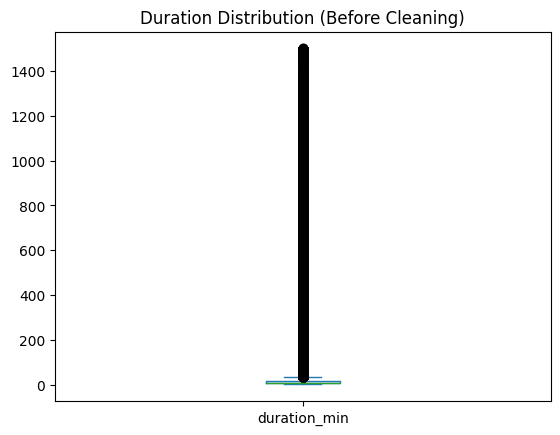

In [ ]:
# CELL 18 — — Visualize Outliers BEFORE Cleaning

plt.figure()
df_seasonal['duration_min'].plot(kind='box')
plt.title("Duration Distribution (Before Cleaning)")

In [ ]:
# CELL 19 — IQR Analysis (Separate from Cleaning Rule)

IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

upper_fence

# Important:
# IQR identifies statistical outliers
# BUT may remove valid longer rides
# Therefore used for understanding, not cleaning

np.float64(31.657487499999995)

In [ ]:
# CELL 20 —  Define Threshold (Final Decision)
# Combine statistical insight + domain knowledg
total_rows = len(df_seasonal)
invalid_rows = ((df_seasonal['duration_min'] <= 0) |
                (df_seasonal['duration_min'] > 1440)).sum()

total_rows, invalid_rows, invalid_rows / total_rows
# Numbr of rides with imposble durations. Less or equal 0 or bigger than 1440
# expected 2278 equivalent to 0.0198%

(11478343, np.int64(2278), np.float64(0.00019846070116566478))

In [ ]:
# CELL 21 — Inspect Outlier Rows

# Look at actual rows to confirm they are invalid

df_seasonal[df_seasonal['duration_min'] > 1440].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duration_min
16058,64660F6EF38A4D01,classic_bike,2025-02-18 14:53:25.602,2025-02-19 15:53:14.470,Rutgers St & Henry St,5230.02,NaN,NaN,40.71,-73.99,NaN,NaN,member,1499.81
16091,4FD377FC9F9348FB,classic_bike,2025-02-20 15:08:18.996,2025-02-21 16:08:13.557,31 Ave & 14 St,6966.04,NaN,NaN,40.77,-73.93,NaN,NaN,casual,1499.91
16188,1E37F9BA434D2468,classic_bike,2025-02-18 16:38:05.555,2025-02-19 17:37:58.765,N 5 St & Northside Piers,5458.02,NaN,NaN,40.72,-73.96,NaN,NaN,member,1499.89
16229,753ED3731B91C4DE,classic_bike,2025-02-15 13:33:41.556,2025-02-16 14:33:21.948,Lenox Ave & W 111 St,7602.05,NaN,NaN,40.80,-73.95,NaN,NaN,casual,1499.67
16230,1FEB3BE498EA2381,classic_bike,2025-02-15 11:10:55.376,2025-02-16 12:10:48.310,7 Ave & Central Park South,6912.01,NaN,NaN,40.77,-73.98,NaN,NaN,casual,1499.88


In [ ]:
# CELL 22 — Clean Dataset

df_seasonal = df_seasonal[
    (df_seasonal['duration_min'] > 0) &
    (df_seasonal['duration_min'] <= 1440)
]

Text(0.5, 1.0, 'Duration Distribution (After Cleaning)')

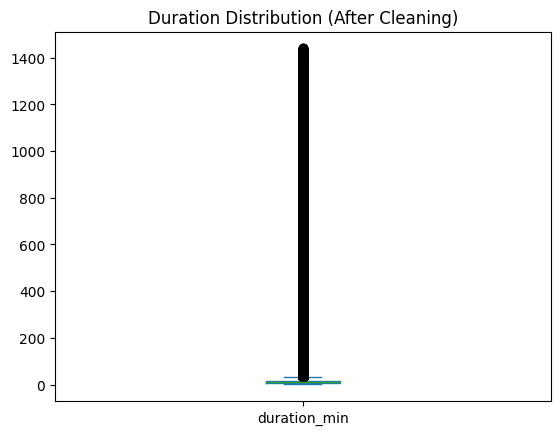

In [ ]:
# CELL 23 — — Visualize AFTER Cleaning

plt.figure()
df_seasonal['duration_min'].plot(kind='box')
plt.title("Duration Distribution (After Cleaning)")

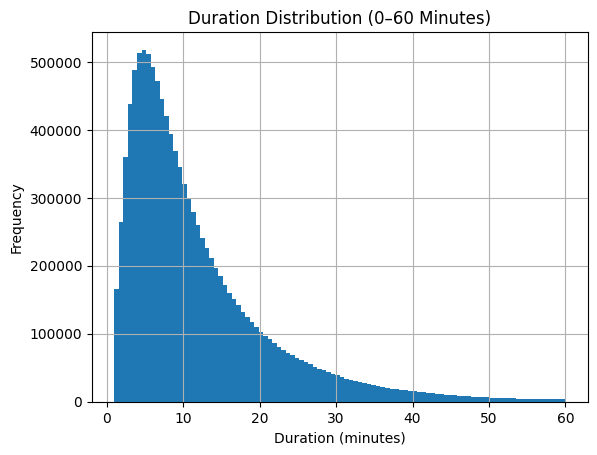

In [ ]:
# CELL 24.1 — Zoomed Distribution (Better Visualization)

import matplotlib.pyplot as plt

df_seasonal[df_seasonal['duration_min'] < 60]['duration_min'].hist(bins=100)

plt.title("Duration Distribution (0–60 Minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# CELL 24 — Dataset Size After Cleaning

print("Cleaned dataset shape:", df_seasonal.shape)

Cleaned dataset shape: (11476065, 14)


In [ ]:
# CELL 25 — Validate Cleaning

(df_seasonal['duration_min'] < 0).sum()
(df_seasonal['duration_min'] > 1440).sum()

np.int64(0)

In [ ]:
# CELL 26 — Remove Missing Data (Final Cleaning Step)

# Now that duration-based outliers have been removed,
# we address missing values in station and location fields.

# From earlier analysis:
# Missing values are very small (<0.3% of the dataset),
# so removing them will NOT impact overall results.

# These fields are critical for:
#    station analysis
#    geographic mapping
#    trip origin/destination insights

# Therefore, rows with missing station or location data are removed.

df_seasonal = df_seasonal.dropna(
    subset=[
        'start_station_name',
        'start_station_id',
        'end_station_name',
        'end_station_id',
        'start_lat',
        'start_lng',
        'end_lat',
        'end_lng'
    ]
)

# Check dataset size after removing missing values
print("Dataset shape after removing missing values:", df_seasonal.shape)


Dataset shape after removing missing values: (11444071, 14)


In [ ]:
# CELL 27 — Validate Missing Data Removal

# Confirm that missing values have been removed successfully

df_seasonal.isnull().sum()

,0
ride_id,0
rideable_type,0
started_at,0
ended_at,0
start_station_name,0
start_station_id,0
end_station_name,0
end_station_id,0
start_lat,0
start_lng,0


In [ ]:
# CELL 28 — Final Dataset Validation (Complete Check)

# Verify:
#  no invalid durations
#  no missing values

(df_seasonal['duration_min'] < 0).sum()
(df_seasonal['duration_min'] > 1440).sum()

df_seasonal.isnull().sum()

# Final dataset size
df_seasonal.shape

(11444071, 14)

In [ ]:
# CELL 29 — Phase 2: Data Wrangling / Enrichment

# Goal of Phase 2:
# Transform clean data into analytical data

# At this stage:
# ✔ Data is already cleaned and validated (Phase 1 complete)
# ✔ No invalid durations
# ✔ No missing critical fields

# Now we enrich the dataset by creating new features (columns)
# that will help answer key business questions:

# Questions we want to answer:
# - When do people ride?
# - Who rides more?
# - What times are busiest?
# - Which stations are busiest?
# - How long are the trips?
# - How does ridership change by season?

# Strategy:
# Create reusable columns (features) that simplify analysis in Tableau

# Important Rule:
#  Create reusable logic here
#  Leave aggregations and dashboards for Tableau

print("Phase 2 — Data Enrichment Started")


Phase 2 — Data Enrichment Started


In [ ]:
# CELL 30 — Extract Time-Based Features

# Extract hour, day, and month from timestamp
# These columns help answer:
#   When people ride
#   Peak hours
#   Weekly patterns

df_seasonal['hour'] = df_seasonal['started_at'].dt.hour
df_seasonal['day_of_week'] = df_seasonal['started_at'].dt.day_name()
df_seasonal['month'] = df_seasonal['started_at'].dt.month

# Preview results
df_seasonal[['started_at', 'hour', 'day_of_week', 'month']].head()

# Check structure (confirm new columns added)
df_seasonal.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11444071 entries, 0 to 11478342
Data columns (total 17 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
 13  duration_min        float64       
 14  hour                int32         
 15  day_of_week         object        
 16  month               int32         
dtypes: datetime64[ns](2), float64(5), int32(2), object(8)
memory usage: 1.4+ GB


In [ ]:
# CELL 31 — Weekend / Weekday Indicator

# Identify leisure vs commuting behavior

df_seasonal['is_weekend'] = df_seasonal['day_of_week'].isin(['Saturday', 'Sunday'])

# Preview results
df_seasonal[['day_of_week', 'is_weekend']].head()


,day_of_week,is_weekend
0,Friday,False
1,Monday,False
2,Tuesday,False
3,Friday,False
4,Sunday,True


In [ ]:
# CELL 32 — Map Month to Season

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_seasonal['season'] = df_seasonal['month'].apply(get_season)

# Preview results
df_seasonal[['month', 'season']].head()


,month,season
0,2,Winter
1,2,Winter
2,2,Winter
3,2,Winter
4,2,Winter


In [ ]:
# CELL 33 — Validate Engineered Features

# Check that all new columns exist and are correct

df_seasonal[['hour',
             'day_of_week',
             'month',
             'season',
             'is_weekend']].head()

# Full structure check
df_seasonal.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11444071 entries, 0 to 11478342
Data columns (total 19 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
 13  duration_min        float64       
 14  hour                int32         
 15  day_of_week         object        
 16  month               int32         
 17  is_weekend          bool          
 18  season              object        
dtypes: bool(1), datetime64[ns](2), float64(5), in

In [ ]:
# CELL 34 — Final Dataset Ready for Tableau

# Dataset now contains:
# Clean data (Phase 1)
# Core engineered features (Phase 2)

# Ready to answer:
# - When do people ride
# - Who rides more
# - Peak usage times
# - Seasonal patterns

print("Dataset ready for Tableau ✅")

# Final size
df_seasonal.shape

Dataset ready for Tableau ✅


(11444071, 19)

In [ ]:
# CELL 34.1 Data Analysis / Interpretation and Data Cleaning Justification

# FINAL EXPLANATION — COMPLETE (REAL DATA + SIMPLE)

# We began by analyzing the distribution of trip durations to understand how people use Citi Bikes.

# From the data:
# Q1 (25%) = 5.27 minutes
# Median (50%) = 9.08 minutes
# Q3 (75%) = 15.83 minutes

# This means:
#   25% of rides are shorter than about 5 minutes
#   50% of rides are shorter than about 9 minutes
#   75% of rides are shorter than about 16 minutes

# This shows that most rides are short and fall within a small range.

# However, when looking at the maximum value:
# Max = 1500.81 minutes (~25 hours)

# This is extremely large compared to normal rides,
# which suggests the presence of extreme outliers.

# The data is also right-skewed:
# Mean = 13.36 minutes is higher than the median (9.08 minutes),
# meaning a few large values are pulling the average upward.

# To detect outliers statistically, we used the Interquartile Range (IQR).

# IQR = Q3 - Q1 = 15.83 - 5.27 = 10.56 minutes

# Using IQR, we calculate the upper fence:
# Upper Fence = Q3 + 1.5 × IQR ≈ 15.83 + 15.83 = 31.66 minutes

# This means any ride longer than about 31.66 minutes
# is considered a statistical outlier.

# However, this threshold is too strict for real-world use.

# Many valid rides can last longer than 30 minutes,
# so using this rule alone would remove real and valid data.

# Therefore, we used domain knowledge to make a better decision.

# Citi Bikes are designed for short-term trips,
# usually lasting only a few minutes up to a couple of hours.

# A ride lasting more than 24 hours (1440 minutes)
# is unrealistic and likely represents improper docking or data issues.

# Because of this, we set a threshold of:
# 1440 minutes (24 hours)

# This threshold:
# ✔ Is far above normal ride durations (~15 minutes)
# ✔ Removes extreme anomalies (like 1500 minutes)
# ✔ Keeps all realistic rides

# After applying this threshold,
# the dataset retained its normal distribution
# while removing only the extreme values.

# Conclusion:
# The dataset is now clean, realistic, and ready for accurate analysis,
# without removing valid user behavior.


To enable meaningful analysis of trip behavior, a new feature, duration_min, was engineered by calculating the difference between trip end and start times. This feature was essential for both data interpretation and cleaning. Initial statistical analysis revealed that trip durations were highly concentrated within a small range: the first quartile (Q1) was approximately 5.27 minutes, the median was 9.08 minutes, and the third quartile (Q3) was 15.83 minutes. This indicates that 75% of all rides lasted less than 16 minutes, confirming that Citi Bike usage is primarily for short trips. However, the dataset also contained extreme values, with a maximum duration of approximately 1500.81 minutes (over 25 hours), indicating the presence of significant outliers. Further analysis using the Interquartile Range (IQR ≈ 10.56 minutes) produced an upper fence of approximately 31.66 minutes, suggesting that any ride beyond this value could be considered a statistical outlier. While this method effectively identifies unusually long trips, it was determined to be too restrictive, as it would remove valid longer rides. Therefore, domain knowledge was incorporated, recognizing that Citi Bike trips are intended for short-term use. A more appropriate threshold of 1440 minutes (24 hours) was selected, as it is well beyond realistic trip durations while effectively removing extreme anomalies. This combined approach ensured that the dataset retained legitimate user behavior while eliminating clearly invalid records, resulting in a clean and reliable dataset for further analysis and visualization

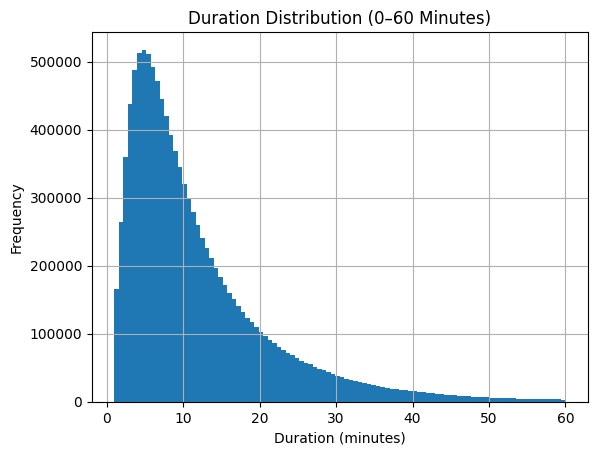

In [ ]:

# CELL 35 — Zoomed Distribution (Better Visualization)

import matplotlib.pyplot as plt

df_seasonal[df_seasonal['duration_min'] < 60]['duration_min'].hist(bins=100)

plt.title("Duration Distribution (0–60 Minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# CELL 35.1 ##  — Optional Sampling for Performance

# Why do this?
# Large datasets can slow down analysis and visualization

# Sampling keeps a random subset of data
# random_state=42 ensures reproducibility (same results each run)

##  df_sample = df_seasonal.sample(frac=0.3, random_state=42)

##  print("Sample dataset shape:", df_sample.shape)

# When to use:
#   Faster plotting
#   Testing models
#   Quick analysis

# Important:
# This does NOT replace the full dataset
# It is only for performance optimization



In [ ]:
# CELL ## 35.2
# Save cleaned dataset ONLY if needed (large file)

## df_seasonal.to_csv("citibike_seasonal_clean.csv", index=False)

In [ ]:
# CELL 39 — Missing Data Percentage (Before Full Cleaning Verification)

# Convert missing values into percentage for easier interpretation
# ratio
missing_percent = df_seasonal.isnull().sum() / len(df_seasonal)

# Display percentages sorted from highest to lowest
missing_percent.sort_values(ascending=False)

,0
ride_id,0.00
rideable_type,0.00
started_at,0.00
ended_at,0.00
start_station_name,0.00
start_station_id,0.00
end_station_name,0.00
end_station_id,0.00
start_lat,0.00
start_lng,0.00


In [ ]:
# CELL 40 — Missing Data (Percentage View)

# Convert missing values to percentage (0–100%)
# Percentage
missing_percent = (df_seasonal.isnull().sum() / len(df_seasonal)) * 100

# Display only columns with missing values > 0
missing_percent[missing_percent > 0].sort_values(ascending=False)

,0


In [ ]:
# CELL 41 Check type counts for start_station_id
# Identify wrong data types.
# Need to clean up.
df_seasonal['start_station_id'].apply(type).value_counts(normalize=True) * 100


,proportion
start_station_id,
<class 'str'>,98.13
<class 'float'>,1.87


In [ ]:
# CELL 42 — Validate Internal Types for All Columns using Dictionary DataType

# We will check each column to see if it contains mixed types

type_summary = {}

for col in df_seasonal.columns:
    type_counts = df_seasonal[col].apply(type).value_counts(normalize=True) * 100
    type_summary[col] = type_counts

type_summary
###  ----

{'ride_id': ride_id
 <class 'str'>   100.00
 Name: proportion, dtype: float64,
 'rideable_type': rideable_type
 <class 'str'>   100.00
 Name: proportion, dtype: float64,
 'started_at': started_at
 <class 'pandas._libs.tslibs.timestamps.Timestamp'>   100.00
 Name: proportion, dtype: float64,
 'ended_at': ended_at
 <class 'pandas._libs.tslibs.timestamps.Timestamp'>   100.00
 Name: proportion, dtype: float64,
 'start_station_name': start_station_name
 <class 'str'>   100.00
 Name: proportion, dtype: float64,
 'start_station_id': start_station_id
 <class 'str'>     98.13
 <class 'float'>    1.87
 Name: proportion, dtype: float64,
 'end_station_name': end_station_name
 <class 'str'>   100.00
 Name: proportion, dtype: float64,
 'end_station_id': end_station_id
 <class 'str'>     81.47
 <class 'float'>   18.53
 Name: proportion, dtype: float64,
 'start_lat': start_lat
 <class 'float'>   100.00
 Name: proportion, dtype: float64,
 'start_lng': start_lng
 <class 'float'>   100.00
 Name: proporti

In [ ]:
# CELL 43 — Fix Type Consistency before convering data for Parquet file compression
# Convert station ID columns to consistent string type

df_seasonal['start_station_id'] = df_seasonal['start_station_id'].astype(str)
df_seasonal['end_station_id'] = df_seasonal['end_station_id'].astype(str)

print("Station ID columns standardized ")


Station ID columns standardized 


In [ ]:
# CELL 44 —# Confirm fix worked #

df_seasonal['start_station_id'].apply(type).value_counts()
df_seasonal['end_station_id'].apply(type).value_counts()

,count
end_station_id,
<class 'str'>,11444071


In [ ]:
# CELL 45 — Mount Google Drive

# This step connects your Colab notebook to Google Drive
# so you can save your dataset and access it later

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# CELL 46 — Create Folder in Google Drive

import os

folder_path = '/content/drive/MyDrive/CitibikeDataSets'

os.makedirs(folder_path, exist_ok=True)

print("Folder 'CitibikeDataSets' is ready ")


Folder 'CitibikeDataSets' is ready 


In [ ]:
# CELL 47 — Define File Paths

# Define where the files will be saved inside Google Drive

parquet_path = '/content/drive/MyDrive/CitibikeDataSets/citibike_clean.parquet'
csv_path = '/content/drive/MyDrive/CitibikeDataSets/citibike_clean.csv'

print("Paths ready ")




Paths ready 


In [ ]:
# CELL 48  — Save Dataset (Parquet Format)

# Parquet is the recommended format:
# ✔ smaller file size
# ✔ faster performance
# ✔ preserves data types (important for Tableau)

## df_seasonal.to_parquet(parquet_path, index=False)

## print("Parquet file saved successfully ")



In [ ]:
# CELL 49 — Save Dataset (Parquet Format)

# Save cleaned and enriched dataset

df_seasonal.to_parquet(parquet_path, index=False)

print("Parquet file saved ✅")

Parquet file saved ✅


In [ ]:
# CELL 51 Validate File in Google Drive

import os

os.listdir('/content/drive/MyDrive/CitibikeDataSets')



['citibike_clean.parquet']

In [ ]:
# CELL 47 — Save Dataset (CSV Format)

# Save dataset as CSV for compatibility (Excel, sharing, backup)

csv_path = '/content/drive/MyDrive/CitibikeDataSets/citibike_clean.csv'

df_seasonal.to_csv(csv_path, index=False)

print("CSV file saved successfully ✅")


CSV file saved successfully ✅


In [ ]:
# CELL 54 — Validate CSV File in Drive

import os
os.listdir('/content/drive/MyDrive/CitibikeDataSets')


['citibike_clean.parquet', 'citibike_clean.csv']

In [ ]:
# CELL 55 — Final Dataset Shape

# Check number of rows and columns after all cleaning and enrichment

df_seasonal.shape

(11444071, 19)

In [ ]:
# CELL 56 — Final Project Summary & Next Steps (Tableau)

# Project Summary
# The dataset has been successfully:
# - Cleaned (removed invalid durations and missing values)
# - Validated (no NaN / NaT and no unrealistic values remain)
# - Enriched (new features created for analysis)
# - Prepared for visualization

# New features created include:
# - duration_min → trip duration
# - hour → hour of the ride
# - day_of_week → weekday name
# - month → numeric month
# - is_weekend → weekend vs weekday behavior
# - season → seasonal grouping

# These features allow us to analyze:
# - Who uses Citi Bike (member vs casual)
# - When people ride (time patterns)
# - How long trips last
# - Which stations are most popular

# Business Questions to Answer in Tableau

# 1. User Behavior
# - Who uses Citi Bike the most?
#   → Members vs Casual riders
#
# 2. Usage Patterns (When)
# - What time of day are bikes used the most?
# - What days of the week show highest activity?
# - Do usage patterns differ on weekends?
# - How do riding patterns change by season?
#
# 3. Trip Behavior
# - What is the average ride duration?
# - How does trip duration differ by user type?
#
# 4. Station Analysis
# - What are the most popular start stations?
# - What are the most popular end stations?

# Tableau Approach

# In Tableau, this analysis will be implemented using:
# - Worksheets → individual charts (bar, line, histogram)
# - Dashboards → combining multiple charts into one view
# - Story → presenting insights step-by-step (Storytelling)

# This project will use Tableau Storytelling to:
# - Answer questions logically and progressively
# - Communicate insights clearly
# - Provide a complete analytical narrative

# Why We Use Parquet Instead of CSV

# Parquet format is used because:

# - Smaller file size
#   → Faster upload and download

# - Faster performance
#   → Tableau reads Parquet more efficiently than CSV

# - Data type preservation
#   → Keeps numeric, datetime, and categorical types correctly
#   → CSV may convert everything to text

# - Optimized for large datasets
#   → Important for ~11M rows in this project

# CSV is still saved as a backup for compatibility,
# but Parquet is the primary file used for Tableau analysis.

# Next Step

# Import the Parquet file into Tableau Desktop (2025.2)
# and begin building dashboards to answer the business questions above.

print("Data preparation complete. Ready for Tableau analysis")

Data preparation complete. Ready for Tableau analysis
